In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import scipy.io
# import cartopy.feature as cfeature
# import cartopy.crs as ccrs
import xarray as xr
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'xarray'

In [2]:
def coriolis_force(lat):
    omega = 2 * np.pi / (24 * 60 * 3600)
    f = 2 * omega * np.sin(lat)
    return f

In [3]:
g = 9.8
nu = 10**(-3)

In [4]:
uo_infile = 'http://apdrc.soest.hawaii.edu:80/dods/public_data/Reanalysis_Data/ORAS4/uo'
vo_infile = 'http://apdrc.soest.hawaii.edu:80/dods/public_data/Reanalysis_Data/ORAS4/vo'
zos_infile = 'http://apdrc.soest.hawaii.edu:80/dods/public_data/Reanalysis_Data/ORAS4/zos'

data_uo = xr.open_dataset(uo_infile)
data_vo = xr.open_dataset(vo_infile)
data_ssh = xr.open_dataset(zos_infile)

surface_uo = data_uo.sel(lev=data_uo.lev[0]) # Choosing the highest depth cuz dropping lev drops the variable
surface_vo = data_vo.sel(lev=data_vo.lev[0])

years = data_uo.time.values # In a datatime format, better to use this for plotting, and integers for training

data_uo = surface_uo.drop('lev') # Not needed, correspond to z-axis
data_vo = surface_vo.drop('lev')

u_sel = data_uo.sel(lat=slice(30, 60), lon=slice(150, 250))
v_sel = data_vo.sel(lat=slice(30, 60), lon=slice(150, 250))
ssh_sel = data_ssh.sel(lat=slice(30, 60), lon=slice(150, 250))

u_sel['time'] = np.arange(years.shape[0])
v_sel['time'] = np.arange(years.shape[0])
ssh_sel['time'] = np.arange(years.shape[0])

lat = u_sel.lat.values # Corresponds to y
lon = u_sel.lon.values # Corresponds to x

u = u_sel['uo'].values # (T, N, M)
v = v_sel['vo'].values # (T, N, M)
ssh = ssh_sel['ssh'].values # (T, N, M)

C:\Users\angel\anaconda3\Lib\site-packages\xarray\coding\times.py:154: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)


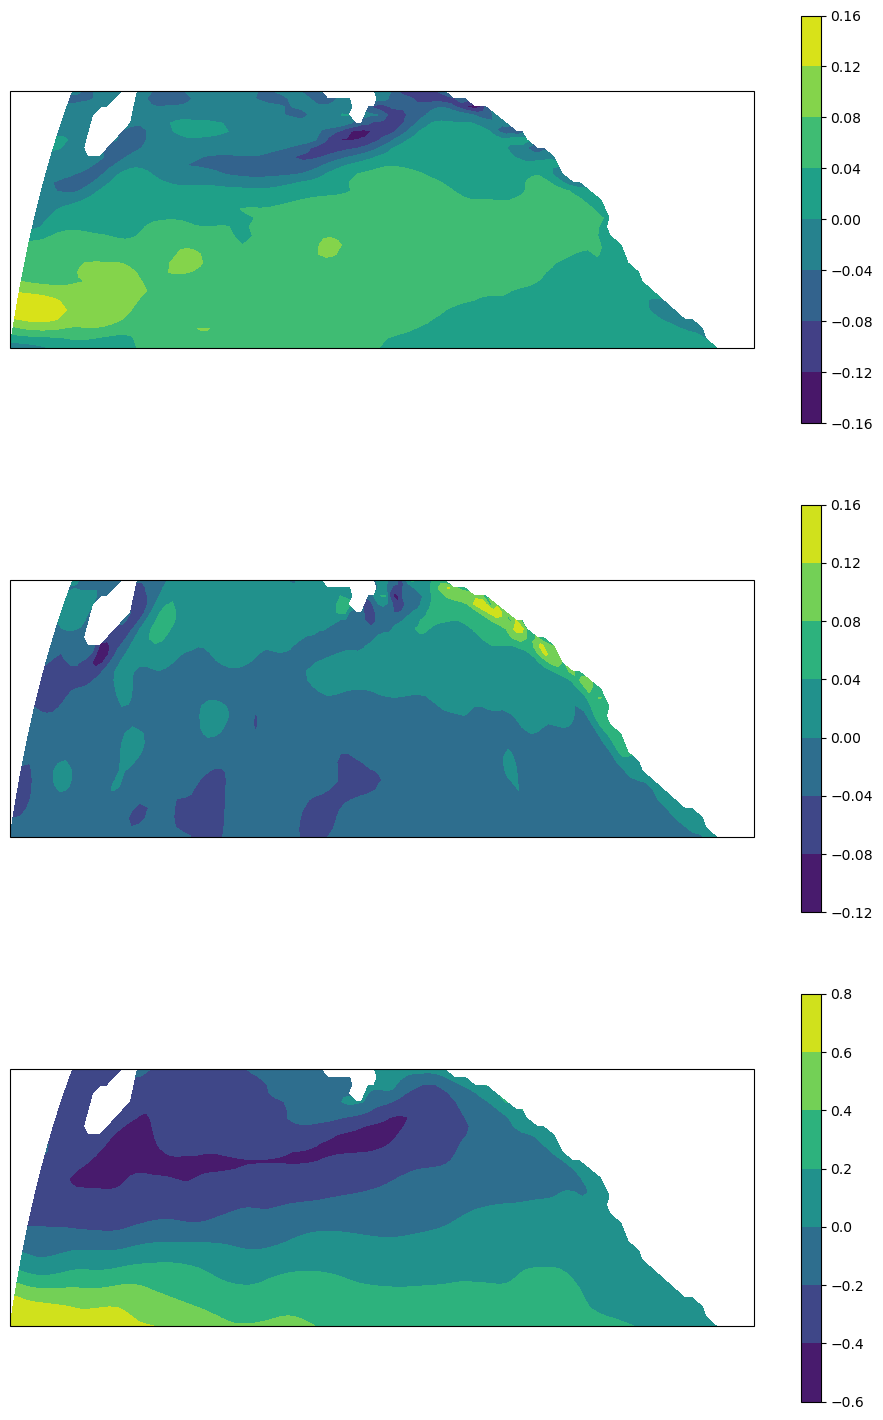

In [5]:
projection = ccrs.Mollweide(central_longitude=180)

fig, ax = plt.subplots(3, 1, figsize=(12, 18), subplot_kw={'projection': projection})

U_plot = u_sel['uo'][0,:,:].values
V_plot = v_sel['vo'][0,:,:].values
SSH_plot = ssh_sel['ssh'][0,:,:].values

pcf0 = ax[0].contourf(lon, lat, U_plot, transform=ccrs.PlateCarree(), cmap='viridis') # Same as plotting xarray
pcf1 = ax[1].contourf(lon, lat, V_plot, transform=ccrs.PlateCarree(), cmap='viridis')
pcf2 = ax[2].contourf(lon, lat, SSH_plot, transform=ccrs.PlateCarree(), cmap='viridis')

cbar0 = fig.colorbar(pcf0, ax=ax[0])
cbar1 = fig.colorbar(pcf1, ax=ax[1])
cbar2 = fig.colorbar(pcf2, ax=ax[2])

def update(frame): 
    ax[0].clear()
    ax[1].clear()
    ax[2].clear()

    U_plot = u_sel['uo'][frame,:,:].values
    V_plot = v_sel['vo'][frame,:,:].values
    SSH_plot = ssh_sel['ssh'][frame,:,:].values

    ax[0].contourf(lon, lat, U_plot, transform=ccrs.PlateCarree(), cmap='viridis') # Same as plotting xarray
    ax[1].contourf(lon, lat, V_plot, transform=ccrs.PlateCarree(), cmap='viridis')
    ax[2].contourf(lon, lat, SSH_plot, transform=ccrs.PlateCarree(), cmap='viridis')

    ax[0].set_title(f'U velocity at {years[frame]}')
    ax[1].set_title(f'V velocity at {years[frame]}')
    ax[2].set_title(f'Pressure at {years[frame]}')
    
    ax[0].coastlines()
    ax[0].add_feature(cfeature.BORDERS)
    ax[0].gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)
    
    ax[1].coastlines()
    ax[1].add_feature(cfeature.BORDERS)
    ax[1].gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)
    
    ax[2].coastlines()
    ax[2].add_feature(cfeature.BORDERS)
    ax[2].gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)

ani = animation.FuncAnimation(fig, update, frames=years.shape[0], interval=1)
#ani.save('contour_true.gif')
plt.show()

C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\animation.py:892: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


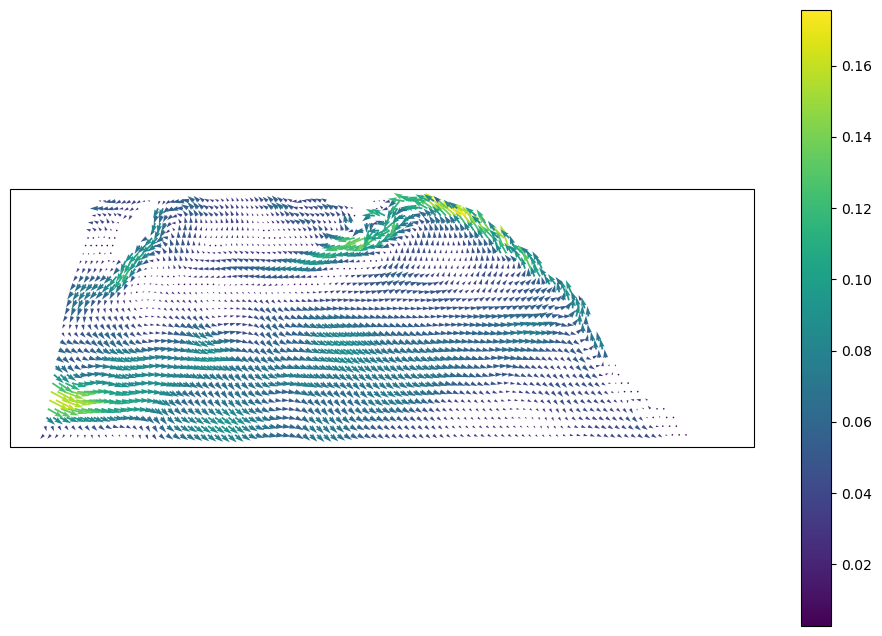

In [6]:
projection = ccrs.Mollweide(central_longitude=180)

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': projection})

U_plot = u_sel['uo'][0,:,:].values
V_plot = v_sel['vo'][0,:,:].values

c = np.sqrt(U_plot**2 + V_plot**2)  # The magnitude used in the colormap
quiver = ax.quiver(lon, lat, U_plot, V_plot, c, transform=ccrs.PlateCarree())

cbar = fig.colorbar(quiver, ax=ax)

def update(frame): 
    ax.clear()

    U_plot = u_sel['uo'][frame,:,:].values
    V_plot = v_sel['vo'][frame,:,:].values

    c = np.sqrt(U_plot**2 + V_plot**2)  # The magnitude used in the colormap
    ax.quiver(lon, lat, U_plot, V_plot, c, transform=ccrs.PlateCarree())

    ax.set_title(years[frame])
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)

ani = animation.FuncAnimation(fig, update, frames=years.shape[0], interval=1)
#ani.save('quiver_true.gif')
plt.show()

In [6]:
non_nan = np.where(~np.isnan(u[0, :, :]))
X = lon[non_nan[1]][:, None] # (n, 1)
Y = lat[non_nan[0]][:, None] # (n, 1)
T = u_sel.time.values[:, None] # (T, 1)

N = lat.shape[0]
M = lon.shape[0]
t = u_sel.time.values.shape[0]
n = Y.shape[0]

X_total = np.tile(X, T.shape[0]) # (n, t) same as doing np.tile(X, (1, T)) by np.array_equal, doing tranpose does the opposite
Y_total = np.tile(Y, T.shape[0]) # (n, t)
T_total = np.tile(T, (1, X.shape[0])).T # (n, t)
U_total = u[:, non_nan[0], non_nan[1]].T  # (n, T)
V_total = v[:, non_nan[0], non_nan[1]].T  # (n, T)
SSH_total = ssh[:, non_nan[0], non_nan[1]].T  # (n, T)

XX = X_total.flatten()[:, None] # (n * t, 1)
YY = Y_total.flatten()[:, None] # (n * t, 1)
TT = T_total.flatten()[:, None] # (n * t, 1)
UU = U_total.flatten()[:, None] # (n * t, 1)
VV = V_total.flatten()[:, None] # (n * t, 1)
SSH = SSH_total.flatten()[:, None] # (n * t, 1)

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
scaler_t = MinMaxScaler()

scaler_x.fit(XX) # Fitting the entire data to be more accurate
scaler_y.fit(YY)
scaler_t.fit(TT)

scaler_u = MinMaxScaler()
scaler_v = MinMaxScaler()
scaler_ssh = MinMaxScaler()

scaler_u.fit(UU)
scaler_v.fit(VV)
scaler_ssh.fit(SSH)

N_train = 25000
indices = np.random.choice(XX.shape[0], N_train, replace=False) # Cuz cannot handle every point

x_train, x_val, y_train, y_val, t_train, t_val, u_train, u_val, v_train, v_val, ssh_train, ssh_val = train_test_split(
    XX[indices], 
    YY[indices], 
    TT[indices], 
    UU[indices], 
    VV[indices], 
    SSH[indices], 
    test_size=0.2, # 80%/20% Split
    random_state=0
)

x_train = torch.tensor(scaler_x.transform(x_train), dtype=torch.float32, requires_grad=True)
y_train = torch.tensor(scaler_y.transform(y_train), dtype=torch.float32, requires_grad=True)
t_train = torch.tensor(scaler_t.transform(t_train), dtype=torch.float32, requires_grad=True)

u_train = torch.tensor(u_train, dtype=torch.float32)
v_train = torch.tensor(v_train, dtype=torch.float32)
ssh_train = torch.tensor(ssh_train, dtype=torch.float32)

x_test = torch.tensor(scaler_x.transform(X), dtype=torch.float32, requires_grad=True) # Using same scaler to be consistent
y_test = torch.tensor(scaler_y.transform(Y), dtype=torch.float32, requires_grad=True)

x_val = torch.tensor(scaler_x.transform(x_val), dtype=torch.float32, requires_grad=True)
y_val = torch.tensor(scaler_x.transform(y_val), dtype=torch.float32, requires_grad=True)
t_val = torch.tensor(scaler_x.transform(t_val), dtype=torch.float32, requires_grad=True)

u_val = torch.tensor(scaler_x.transform(u_val), dtype=torch.float32)
v_val = torch.tensor(scaler_x.transform(v_val), dtype=torch.float32)
ssh_val = torch.tensor(scaler_x.transform(ssh_val), dtype=torch.float32)

# u_test = torch.tensor(U_total, dtype=torch.float32) # Made but never used
# v_test = torch.tensor(V_total, dtype=torch.float32)
# ssh_test = torch.tensor(SSH_total, dtype=torch.float32)

In [7]:
# batch_size = 64
# train_dataset = TensorDataset(x_train, y_train, t_train, u_train, v_train, ssh_train)
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # Not sure shuffle is the best with time

In [8]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.fc1 = nn.Linear(3, 50)
        self.fc2 = nn.Linear(50, 50)
        self.fc3 = nn.Linear(50, 50)
        self.fc4 = nn.Linear(50, 50)
        self.fc5 = nn.Linear(50, 50)
        self.fc6 = nn.Linear(50, 3)

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        x = torch.sigmoid(self.fc5(x))
        x = self.fc6(x)
        return x

In [9]:
def loss_phys(f_x, f_y, c):
    return torch.mean((f_x - 0)**2 + (f_y - 0)**2 + (c - 0)**2)

In [10]:
def loss_data(u, v, ssh, u_train, v_train, ssh_train): 
    return torch.mean((u - u_train)**2 + (v - v_train)**2 + (ssh - ssh_train)**2)
    # return torch.mean((u - u_train)**2 + (v - v_train)**2 + (ssh - p_train)**2)

In [11]:
def function(x, y, t):
    predict = model(torch.hstack((x, y, t)))
    psi = predict[:, 0:1]
    ssh = predict[:, 1:2]

    u = torch.autograd.grad(psi, y, grad_outputs=torch.ones_like(psi), create_graph=True)[0]
    v = -1 * torch.autograd.grad(psi, x, grad_outputs=torch.ones_like(psi), create_graph=True)[0]

    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]

    v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, grad_outputs=torch.ones_like(v_y), create_graph=True)[0]

    ssh_x = torch.autograd.grad(ssh, x, grad_outputs=torch.ones_like(ssh), create_graph=True)[0]
    ssh_y = torch.autograd.grad(ssh, y, grad_outputs=torch.ones_like(ssh), create_graph=True)[0]

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    v_t = torch.autograd.grad(v, t, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    
    u = torch.tensor(scaler_u.inverse_transform(u.detach().numpy()), dtype=torch.float32)
    v = torch.tensor(scaler_v.inverse_transform(v.detach().numpy()), dtype=torch.float32)
    ssh = torch.tensor(scaler_ssh.inverse_transform(ssh.detach().numpy()), dtype=torch.float32)

    scale_x = scaler_x.scale_[0] 
    scale_y = scaler_y.scale_[0]
    scale_t = scaler_t.scale_[0]
    
    u_x = u_x / scale_x
    u_xx = u_xx / (scale_x**2)
    u_y = u_y / scale_y
    u_yy = u_yy / (scale_y**2)

    v_x = v_x / scale_x
    v_xx = v_xx / (scale_x**2)
    v_y = v_y / scale_y
    v_yy = v_yy / (scale_y**2)

    ssh_x = ssh_x / scale_x
    ssh_y = ssh_y / scale_y

    u_t = u_t / scale_t
    v_t = v_t / scale_t

    c = u_x + v_y
    
    f_x = u_t + u * u_x + v * u_y + g * ssh_x - nu * (u_xx + u_yy)
    f_y = v_t + u * v_x + v * v_y + g * ssh_y - nu * (v_xx + v_yy)

    return u, v, ssh, f_x, f_y, c

In [12]:
def closure():
    optimizer.zero_grad()
    u_pred, v_pred, ssh_pred, f_x, f_y, c = function(x_train, y_train, t_train)
    loss = loss_data(u_pred, v_pred, ssh_pred, u_train, v_train, ssh_train) + loss_phys(f_x, f_y, c) 
    loss.backward()
    return loss
    
    # batch_loss = 0.0
    # for x_batch, y_batch, t_batch, u_batch, v_batch, ssh_batch in train_loader:
    #     u_pred, v_pred, ssh_pred, f_x, f_y, c = function(x_batch, y_batch, t_batch)
    #     loss = loss_data(u_pred, v_pred, ssh_pred, u_batch, v_batch, ssh_batch) + loss_phys(f_x, f_y, c)
    #     loss.backward()
    #     batch_loss += loss.item() # Print out the average loss 
    # return torch.tensor(batch_loss / len(train_loader))

In [13]:
def evaluate(model, x_val, y_val, t_val, u_val, v_val, ssh_val):
    model.eval()  
    u_pred, v_pred, ssh_pred, f_x, f_y, c = function(x_val, y_val, t_val)
    loss = loss_data(u_pred, v_pred, ssh_pred, u_val, v_val, ssh_val) + loss_phys(f_x, f_y, c) 
    
    return loss


In [14]:
# Training function
def train(model, optimizer, num_epochs = 2000):
    prev_loss = float('inf')  
    for epoch in range(1, num_epochs + 1):
        model.train()
        loss = optimizer.step(closure)
        loss_train.append(loss.item())
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item()}')

        loss_val = evaluate(model, x_val, y_val, t_val, u_val, v_val, ssh_val)
        loss_eval.append(loss_val.item())
        print(f'Epoch [{epoch}/{num_epochs}], Validation Loss: {loss_val.item()}')
        if loss.item() >= prev_loss:
            break # Stop iteration if loss isn't decreasing
        prev_loss = loss.item()

In [15]:
loss_train = []
loss_eval = []

# Initialize model and optimizer
model = PINN()

# LBFGS optimizer best for handling second derivative information and small datasets
# requires a closure() to perform the loss function multiple times, and be consistent
optimizer = optim.LBFGS(model.parameters(), lr = 1, weight_decay=1e-5)
# optimizer = optim.Adam(model.parameters(), lr = 0.001)

# Train the model
train(model, optimizer)

print((loss_train[-1] - loss_eval[-1])**2)

Epoch [1/2000], Loss: 0.31302332878112793
Epoch [1/2000], Validation Loss: 5.343801498413086
Epoch [2/2000], Loss: 0.31500306725502014
Epoch [2/2000], Validation Loss: 5.343801498413086
25.288813661217823


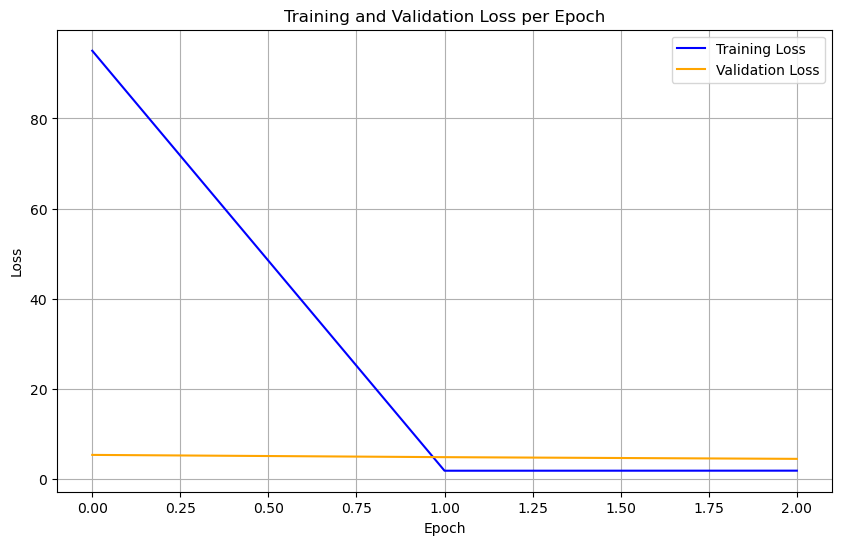

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(loss_train, label='Training Loss', color='blue')
plt.plot(loss_eval, label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\animation.py:892: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


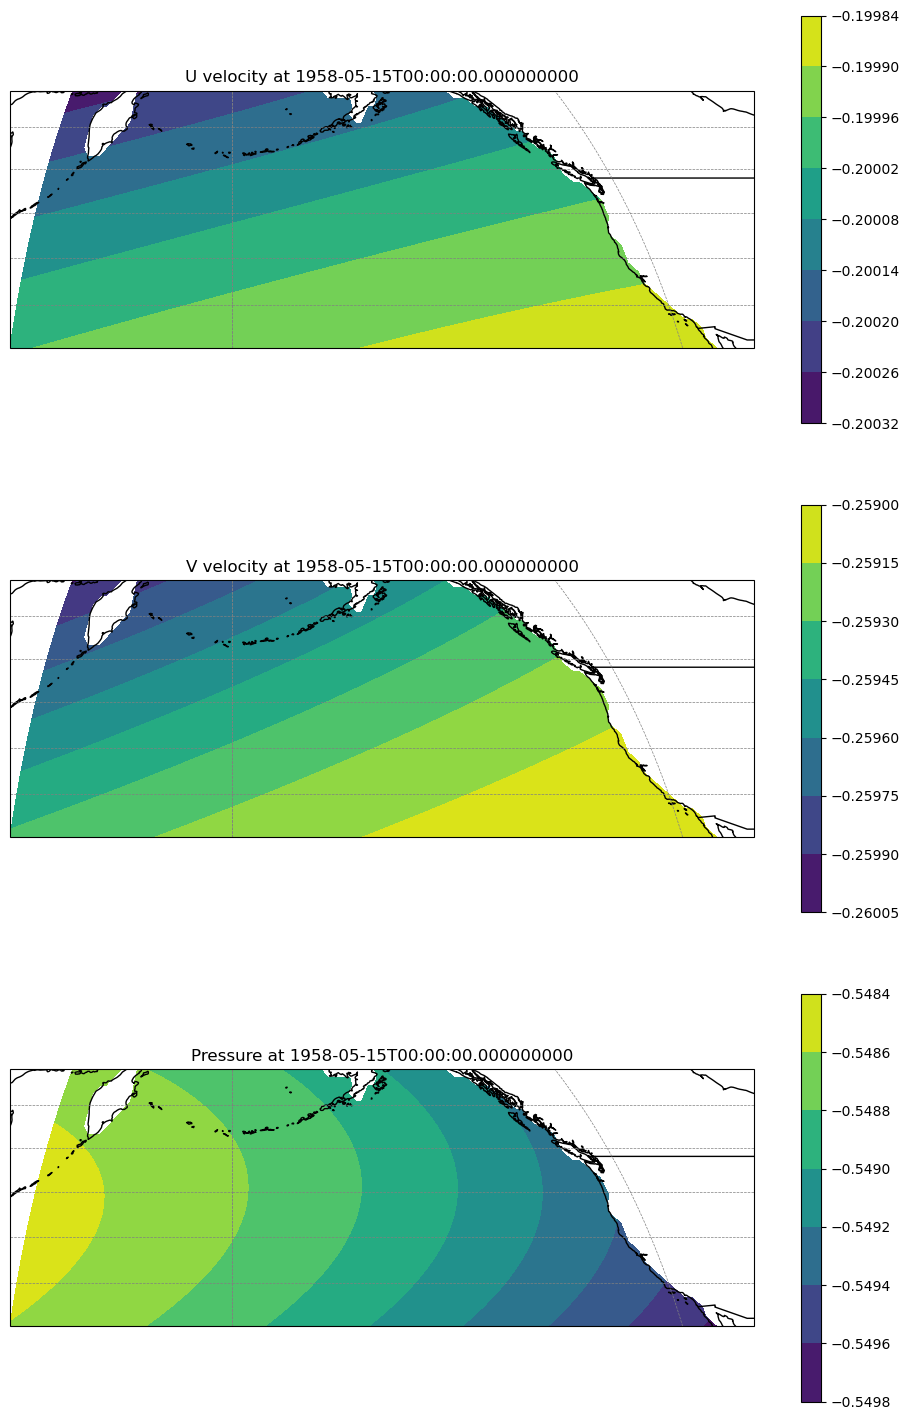

In [51]:
projection = ccrs.Mollweide(central_longitude=180)

fig, ax = plt.subplots(3, 1, figsize=(12, 18), subplot_kw={'projection': projection})

t_test = torch.full(x_test.shape, u_sel['time'].values[0], dtype=torch.float32, requires_grad=True)
u_pred, v_pred, ssh_pred, _ , _ , _ = function(x_test, y_test, t_test * u_sel['time'].values[0])
mask = u[0,:,:].flatten()
indx = np.where(~np.isnan(mask))

U_mask = mask.copy()
U_mask[indx] = u_pred.detach().numpy().flatten()
U_plot = U_mask.reshape(lat.shape[0], lon.shape[0]) 

V_mask = mask.copy()
V_mask[indx] = v_pred.detach().numpy().flatten()
V_plot = V_mask.reshape(lat.shape[0], lon.shape[0]) 

SSH_mask = mask.copy()
SSH_mask[indx] = ssh_pred.detach().numpy().flatten()
SSH_plot = SSH_mask.reshape(lat.shape[0], lon.shape[0]) 

pcf0 = ax[0].contourf(lon, lat, U_plot, transform=ccrs.PlateCarree(), cmap='viridis') # Same as plotting xarray
pcf1 = ax[1].contourf(lon, lat, V_plot, transform=ccrs.PlateCarree(), cmap='viridis')
pcf2 = ax[2].contourf(lon, lat, SSH_plot, transform=ccrs.PlateCarree(), cmap='viridis')

cbar0 = fig.colorbar(pcf0, ax=ax[0])
cbar1 = fig.colorbar(pcf1, ax=ax[1])
cbar2 = fig.colorbar(pcf2, ax=ax[2])

def update(frame): 
    ax[0].clear()
    ax[1].clear()
    ax[2].clear()
    
    t_test = torch.full(x_test.shape, u_sel['time'].values[frame], dtype=torch.float32, requires_grad=True)
    u_pred, v_pred, ssh_pred, _ , _ , _ = function(x_test, y_test, t_test * u_sel['time'].values[frame])
    
    U_mask[indx] = u_pred.detach().numpy().flatten()
    U_plot = U_mask.reshape(lat.shape[0], lon.shape[0]) 
    
    V_mask[indx] = v_pred.detach().numpy().flatten()
    V_plot = V_mask.reshape(lat.shape[0], lon.shape[0]) 
    
    SSH_mask[indx] = ssh_pred.detach().numpy().flatten()
    SSH_plot = SSH_mask.reshape(lat.shape[0], lon.shape[0]) 

    ax[0].contourf(lon, lat, U_plot, transform=ccrs.PlateCarree(), cmap='viridis') # Same as plotting xarray
    ax[1].contourf(lon, lat, V_plot, transform=ccrs.PlateCarree(), cmap='viridis')
    ax[2].contourf(lon, lat, SSH_plot, transform=ccrs.PlateCarree(), cmap='viridis')

    ax[0].set_title(f'U velocity at {years[frame]}')
    ax[1].set_title(f'V velocity at {years[frame]}')
    ax[2].set_title(f'Pressure at {years[frame]}')
    
    ax[0].coastlines()
    ax[0].add_feature(cfeature.BORDERS)
    ax[0].gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)
    
    ax[1].coastlines()
    ax[1].add_feature(cfeature.BORDERS)
    ax[1].gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)
    
    ax[2].coastlines()
    ax[2].add_feature(cfeature.BORDERS)
    ax[2].gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)

ani = animation.FuncAnimation(fig, update, frames=5, interval=1)
ani.save('contour_pred.gif')
plt.show()

C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\quiver.py:645: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\quiver.py:645: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))
C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\quiver.py:645: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\quiver.py:645: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))
C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\quiver.py:645: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\quiver.p

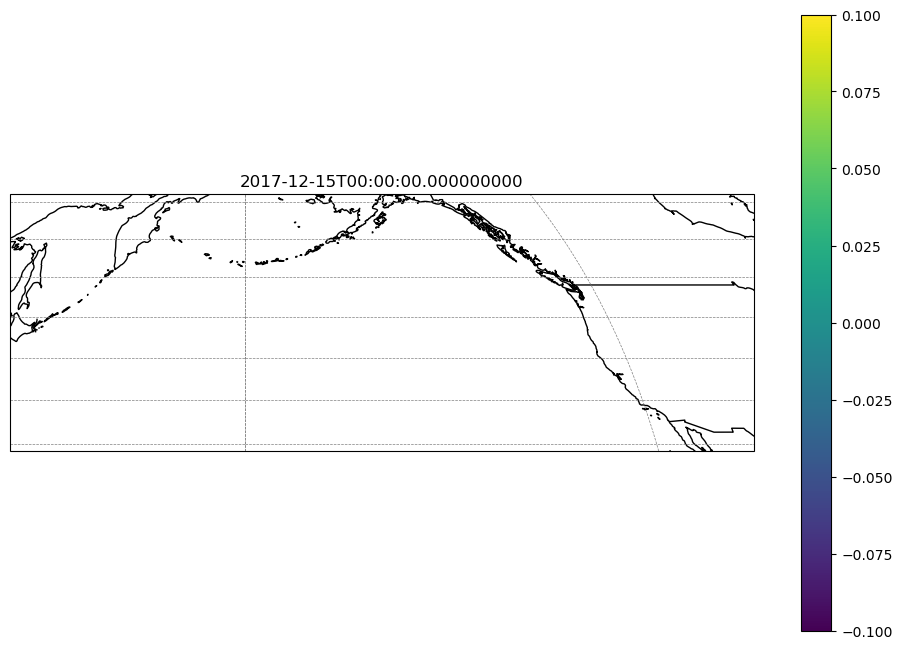

In [27]:
projection = ccrs.Mollweide(central_longitude=180)

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': projection})

t_test = torch.full(x_test.shape, u_sel['time'].values[0], dtype=torch.float32, requires_grad=True)
u_pred, v_pred, ssh_pred, _ , _ , _ = function(x_test, y_test, t_test * u_sel['time'].values[0])
mask = u[0,:,:].flatten()
indx = np.where(~np.isnan(mask))

U_mask = mask.copy()
U_mask[indx] = u_pred.detach().numpy().flatten()
U_plot = U_mask.reshape(lat.shape[0], lon.shape[0]) 

V_mask = mask.copy()
V_mask[indx] = v_pred.detach().numpy().flatten()
V_plot = V_mask.reshape(lat.shape[0], lon.shape[0]) 

c = np.sqrt(U_plot**2 + V_plot**2)  # The magnitude used in the colormap
quiver = ax.quiver(lon, lat, U_plot, V_plot, c, transform=ccrs.PlateCarree())

cbar = fig.colorbar(quiver, ax=ax)

def update(frame): 
    ax.clear()

    t_test = torch.full(x_test.shape, u_sel['time'].values[frame], dtype=torch.float32, requires_grad=True)
    u_pred, v_pred, ssh_pred, _ , _ , _ = function(x_test, y_test, t_test * u_sel['time'].values[frame])

    U_mask[indx] = u_pred.detach().numpy().flatten()
    U_plot = U_mask.reshape(lat.shape[0], lon.shape[0]) 

    V_mask[indx] = v_pred.detach().numpy().flatten()
    V_plot = V_mask.reshape(lat.shape[0], lon.shape[0]) 

    c = np.sqrt(U_plot**2 + V_plot**2)  # The magnitude used in the colormap
    ax.quiver(lon, lat, U_plot, V_plot, c, transform=ccrs.PlateCarree())

    ax.set_title(years[frame])
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)

ani = animation.FuncAnimation(fig, update, frames=years.shape[0], interval=1)
ani.save('quiver_pred.gif')
plt.show()